(1) import libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


(2) upload dataset

In [3]:
df = pd.read_csv(
    "/content/DataCoSupplyChainDataset.csv",
    encoding="cp1252"
)

(3) explore data


In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360.0,73.0,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,1/15/2018 11:24,Standard Class


In [5]:
df.shape

(43652, 53)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43652 entries, 0 to 43651
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           43652 non-null  object 
 1   Days for shipping (real)       43652 non-null  int64  
 2   Days for shipment (scheduled)  43652 non-null  int64  
 3   Benefit per order              43652 non-null  float64
 4   Sales per customer             43652 non-null  float64
 5   Delivery Status                43652 non-null  object 
 6   Late_delivery_risk             43652 non-null  int64  
 7   Category Id                    43652 non-null  int64  
 8   Category Name                  43652 non-null  object 
 9   Customer City                  43651 non-null  object 
 10  Customer Country               43651 non-null  object 
 11  Customer Email                 43651 non-null  object 
 12  Customer Fname                 43651 non-null 

In [7]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,43652.000000,43652.000000,43652.000000,43652.000000,43652.000000,43652.000000,43651.000000,43650.000000,43651.000000,43651.000000,...,43651.000000,43651.000000,43651.000000,43651.00000,5731.000000,43651.000000,43651.000000,0.0,43651.000000,43651.0
mean,3.435948,2.819046,21.465956,176.660852,0.591428,26.671287,6819.670019,35940.647354,4.849007,29.728003,...,2.344414,196.768445,176.659401,21.46459,55191.980981,572.286683,26.671348,NaN,122.566530,0.0
std,1.598678,1.387935,105.476418,126.651869,0.491576,15.197907,4335.589664,37553.248506,1.578346,9.776798,...,1.531570,140.163384,126.652957,105.47724,31816.661406,315.364889,15.198076,NaN,137.713832,0.0
min,0.000000,0.000000,-3366.000000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,17.982491,...,1.000000,9.990000,7.490000,-3366.00000,1453.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,6.437500,97.489998,0.000000,17.000000,3259.000000,725.000000,4.000000,18.265705,...,1.000000,119.970001,97.489998,6.43500,23464.000000,365.000000,17.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,29.230000,141.750000,1.000000,24.000000,6535.000000,19380.000000,5.000000,33.144863,...,2.000000,155.970001,141.750000,29.23000,55901.000000,502.000000,24.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,61.750000,247.500000,1.000000,36.000000,9928.000000,78228.000000,6.000000,39.278959,...,4.000000,299.950012,247.500000,61.75000,90004.000000,793.000000,36.000000,NaN,129.990005,0.0
max,6.000000,4.000000,708.750000,1759.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1759.989990,708.75000,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


(4) find missing values


In [8]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,1


In [9]:
df.duplicated().sum()

np.int64(0)

(5) Handling missing values
   removing columns with high percentege of missing values

In [10]:
df.drop(columns=["Order Zipcode","Product Description"],inplace=True)

In [11]:
df["Customer Lname"]=df["Customer Lname"].fillna("unknowen")

In [12]:
df["Customer Zipcode"] = df["Customer Zipcode"].fillna(df["Customer Zipcode"].mode()[0])

In [13]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,1


In [14]:
df["shipping date (DateOrders)"] = df["shipping date (DateOrders)"].fillna(df["shipping date (DateOrders)"].mode()[0])

In [15]:
df["Shipping Mode"] = df["Shipping Mode"].fillna(df["Shipping Mode"].mode()[0])
df["Order State"] = df["Order State"].fillna(df["Order State"].mode()[0])
df["Order Status"] = df["Order Status"].fillna(df["Order Status"].mode()[0])
df["Product Image"] = df["Product Image"].fillna(df["Product Image"].mode()[0])
df["Product Name"] = df["Product Name"].fillna(df["Product Name"].mode()[0])
df["Product Status"] = df["Product Status"].fillna(df["Product Status"].mode()[0])
df["Product Card Id"] =df["Product Card Id"].fillna("unknowen")
df["Product Category Id"]=df["Product Category Id"].fillna("unknowen")
df["Product Price"] = df["Product Price"].fillna(df["Product Price"].median())

In [16]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,1


change (shipping date / order date) columns type

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43652 entries, 0 to 43651
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           43652 non-null  object 
 1   Days for shipping (real)       43652 non-null  int64  
 2   Days for shipment (scheduled)  43652 non-null  int64  
 3   Benefit per order              43652 non-null  float64
 4   Sales per customer             43652 non-null  float64
 5   Delivery Status                43652 non-null  object 
 6   Late_delivery_risk             43652 non-null  int64  
 7   Category Id                    43652 non-null  int64  
 8   Category Name                  43652 non-null  object 
 9   Customer City                  43651 non-null  object 
 10  Customer Country               43651 non-null  object 
 11  Customer Email                 43651 non-null  object 
 12  Customer Fname                 43651 non-null 

In [18]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43652 entries, 0 to 43651
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Type                           43652 non-null  object        
 1   Days for shipping (real)       43652 non-null  int64         
 2   Days for shipment (scheduled)  43652 non-null  int64         
 3   Benefit per order              43652 non-null  float64       
 4   Sales per customer             43652 non-null  float64       
 5   Delivery Status                43652 non-null  object        
 6   Late_delivery_risk             43652 non-null  int64         
 7   Category Id                    43652 non-null  int64         
 8   Category Name                  43652 non-null  object        
 9   Customer City                  43651 non-null  object        
 10  Customer Country               43651 non-null  object        
 11  Customer Email 

(6) Detect & handle outliers

1ST way boxplot
2ND IQR

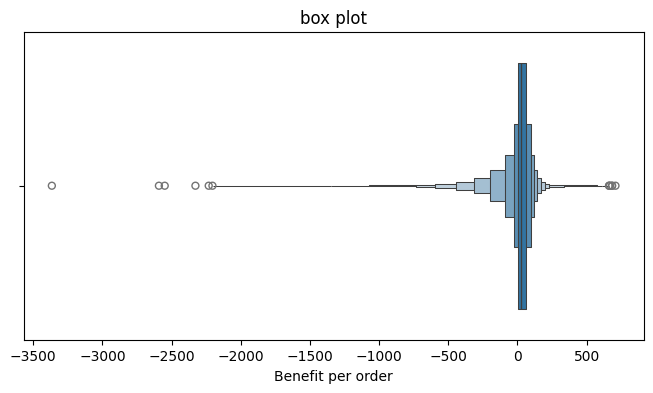

In [20]:
plt.figure(figsize=(8,4))
sns.boxenplot(x=df["Benefit per order"])
plt.title('box plot')
plt.show()


In [21]:
Q1 = df["Benefit per order"].quantile(0.25)
Q3 = df["Benefit per order"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Benefit per order"] = df["Benefit per order"].clip(lower=lower, upper=upper)

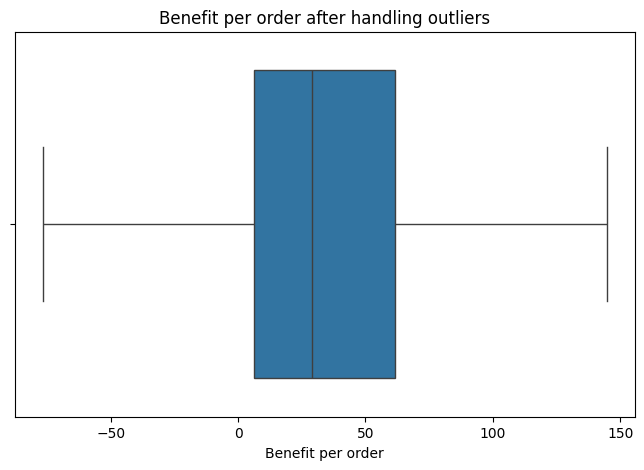

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Benefit per order"])
plt.title("Benefit per order after handling outliers")
plt.show()

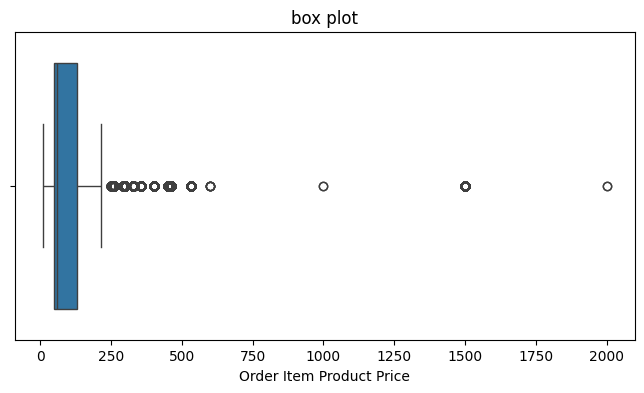

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Product Price"])
plt.title("box plot")
plt.show()

In [24]:
Q1=df["Order Item Product Price"].quantile(0.25)
Q3=df["Order Item Product Price"].quantile(0.75)

IQR=Q3-Q1

lower= Q1- 1.5 *IQR
upper=Q3+1.5*IQR

df["Order Item Product Price"]=df["Order Item Product Price"].clip(lower=lower,upper=upper)

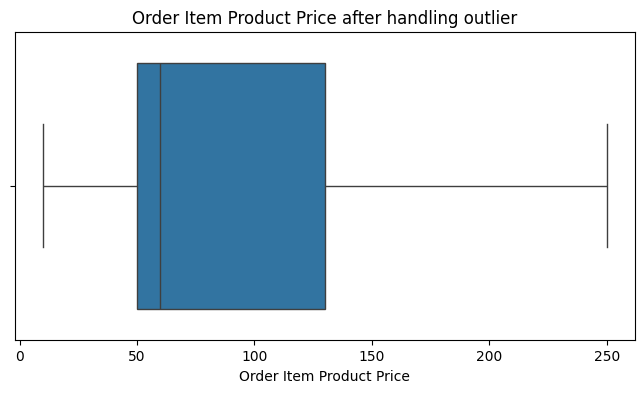

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Product Price"])
plt.title("Order Item Product Price after handling outlier")
plt.show()

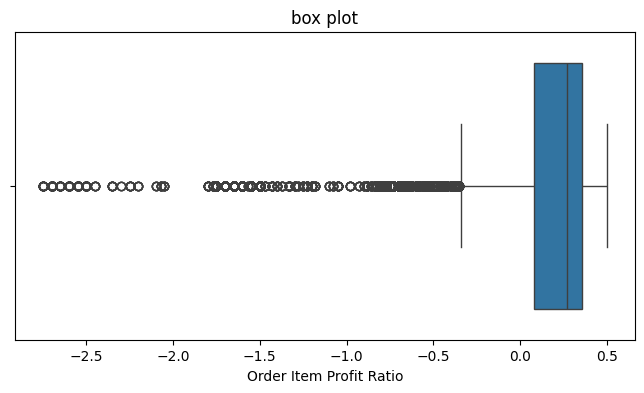

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Profit Ratio"])
plt.title("box plot")
plt.show()

In [27]:
Q1 = df["Order Item Profit Ratio"].quantile(0.25)
Q3 = df["Order Item Profit Ratio"].quantile(0.75)

IQR = Q3-Q1

lower=Q1-1.5 *IQR
upper=Q3+1.5*IQR

df["Order Item Profit Ratio"]=df["Order Item Profit Ratio"].clip(lower=lower,upper=upper)

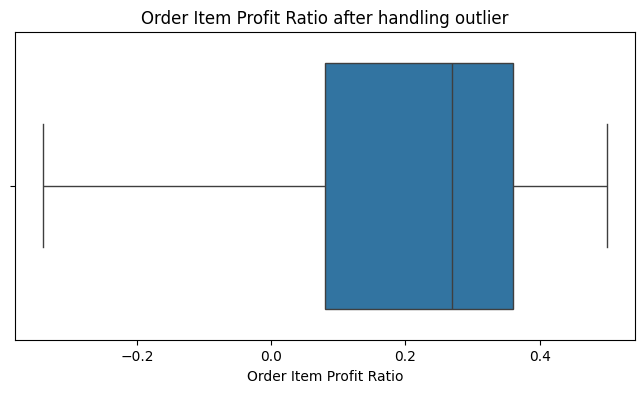

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Profit Ratio"])
plt.title("Order Item Profit Ratio after handling outlier")
plt.show()

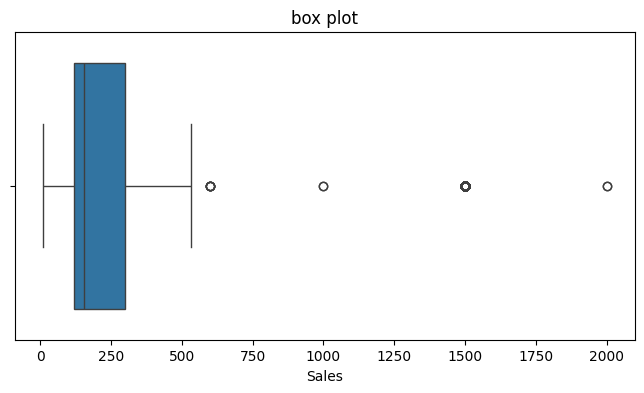

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Sales'])
plt.title("box plot")
plt.show()

In [30]:
Q1=df["Sales"].quantile(0.25)
Q3=df["Sales"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df["Sales"]=df["Sales"].clip(lower=lower,upper=upper)

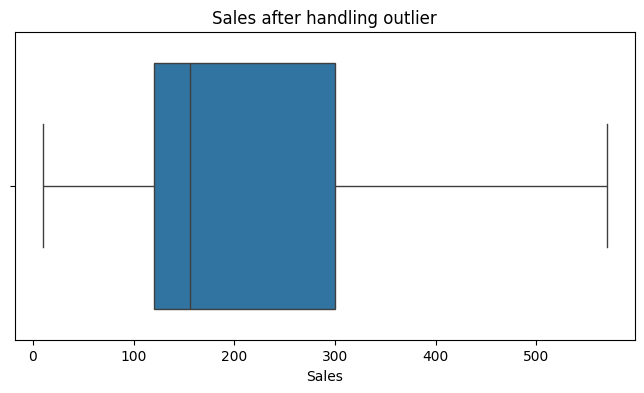

In [31]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales"])
plt.title("Sales after handling outlier")
plt.show()

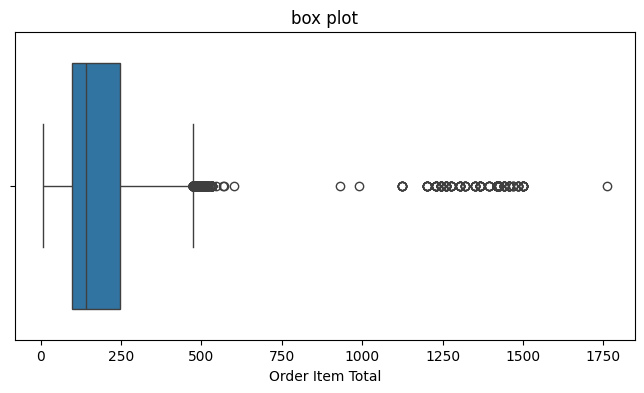

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Total"])
plt.title("box plot")
plt.show()

In [33]:
Q1 = df["Order Item Total"].quantile(0.25)
Q3 = df["Order Item Total"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Order Item Total"] = df["Order Item Total"].clip(lower=lower, upper=upper)

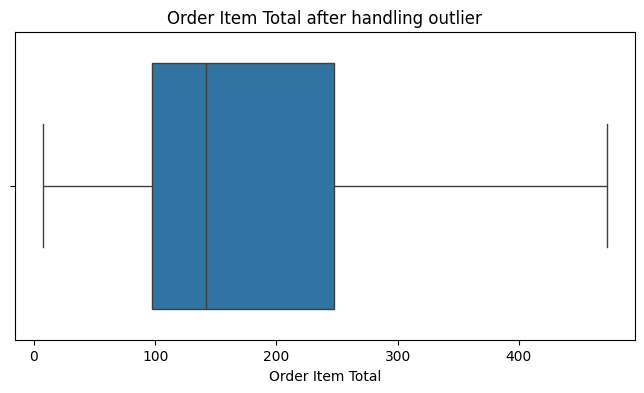

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Total"])
plt.title("Order Item Total after handling outlier")
plt.show()

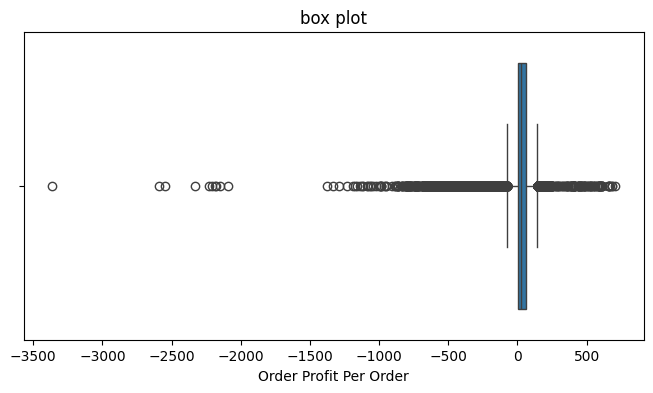

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Profit Per Order"])
plt.title("box plot")
plt.show()

In [36]:
Q1=df["Order Profit Per Order"].quantile(0.25)
Q3=df["Order Profit Per Order"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df["Order Profit Per Order"]=df["Order Profit Per Order"].clip(lower=lower,upper=upper)

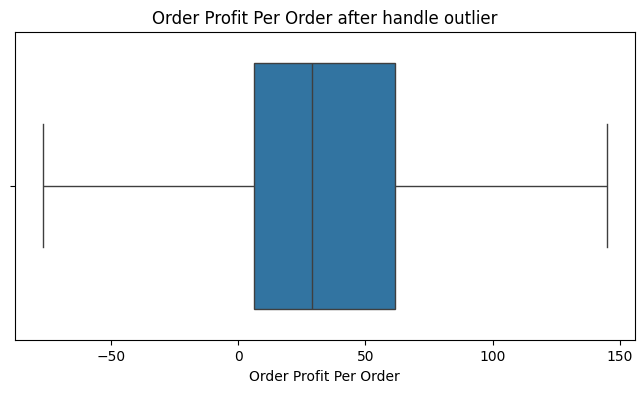

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Profit Per Order"])
plt.title("Order Profit Per Order after handle outlier")
plt.show()

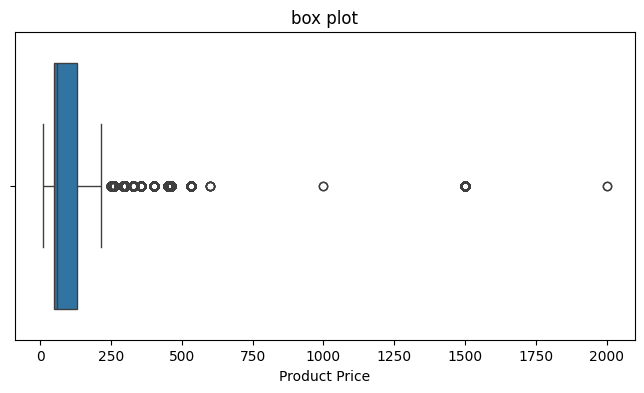

In [38]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Product Price"])
plt.title("box plot")
plt.show()

In [39]:
Q1=df["Product Price"].quantile(0.25)
Q3=df["Product Price"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df["Product Price"]=df["Product Price"].clip(lower=lower,upper=upper)

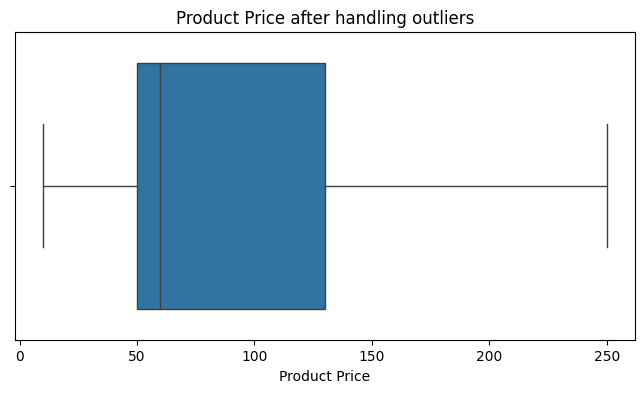

In [40]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Product Price"])
plt.title("Product Price after handling outliers")
plt.show()

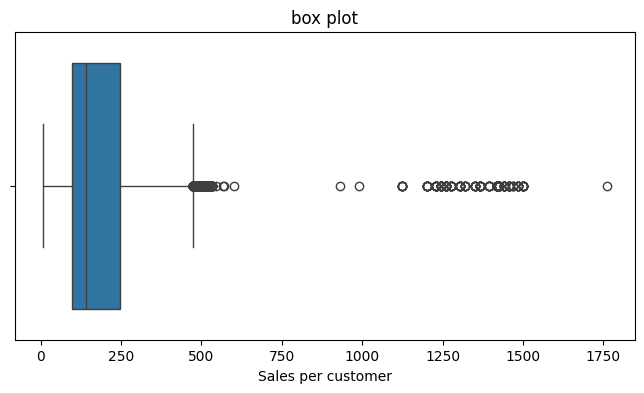

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales per customer"])
plt.title("box plot")
plt.show()

In [42]:
Q1=df["Sales per customer"].quantile(0.25)
Q3=df["Sales per customer"].quantile(0.75)

IQR=Q3-Q1

lower= Q1-1.5*IQR
upper=Q3+1.5*IQR

df["Sales per customer"]=df["Sales per customer"].clip(lower=lower,upper=upper)


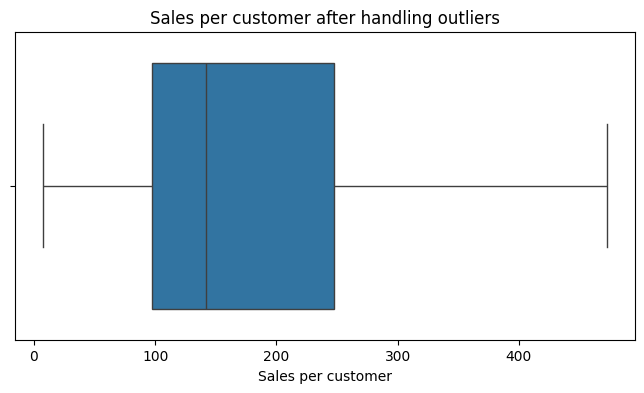

In [43]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales per customer"])
plt.title("Sales per customer after handling outliers")
plt.show()

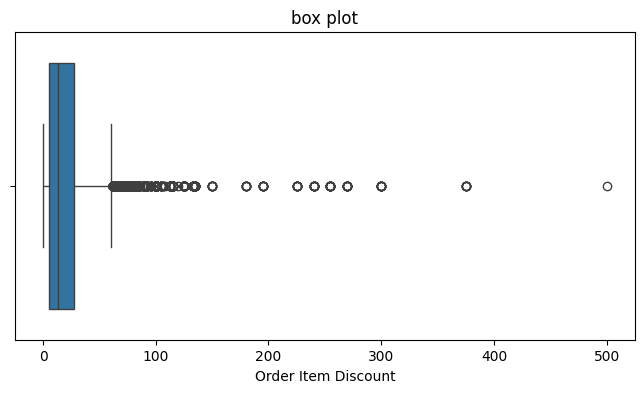

In [44]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Discount"])
plt.title("box plot")
plt.show()

In [45]:
Q1=df["Order Item Discount"].quantile(0.25)
Q3=df["Order Item Discount"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df["Order Item Discount"]=df["Order Item Discount"].clip(lower=lower,upper=upper)

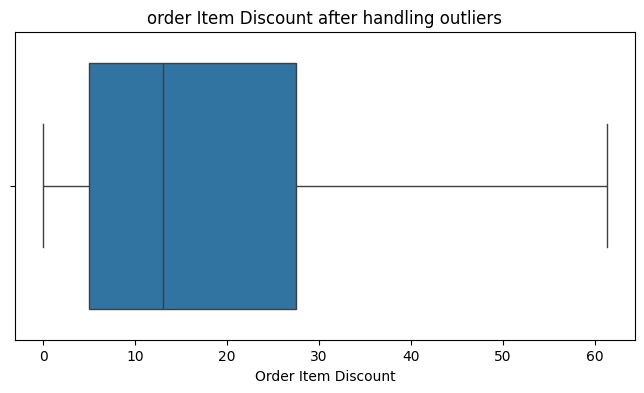

In [46]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Order Item Discount"])
plt.title("order Item Discount after handling outliers")
plt.show()

In [47]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Days for shipping (real): 0 outliers
Days for shipment (scheduled): 0 outliers
Benefit per order: 0 outliers
Sales per customer: 0 outliers
Late_delivery_risk: 0 outliers
Category Id: 1869 outliers
Customer Id: 250 outliers
Customer Zipcode: 0 outliers
Department Id: 760 outliers
Latitude: 0 outliers
Longitude: 366 outliers
Order Customer Id: 250 outliers
Order Id: 0 outliers
Order Item Cardprod Id: 0 outliers
Order Item Discount: 0 outliers
Order Item Discount Rate: 0 outliers
Order Item Id: 0 outliers
Order Item Product Price: 0 outliers
Order Item Profit Ratio: 0 outliers
Order Item Quantity: 0 outliers
Sales: 0 outliers
Order Item Total: 0 outliers
Order Profit Per Order: 0 outliers
Product Price: 0 outliers
Product Status: 0 outliers


Outliers were detected using the IQR method. Financial and continuous numerical columns were treated using the IQR capping technique. Identifier columns (Category Id, Department Id) and geographic coordinates (Longitude) were excluded from outlier treatment because their values represent categorical identifiers and spatial coordinates rather than continuous measurements

(7) skewness

In [48]:
df.select_dtypes(include=["int64", "float64"]).skew()

,0
Days for shipping (real),0.219026
Days for shipment (scheduled),-0.520522
Benefit per order,-0.066423
Sales per customer,0.775137
Late_delivery_risk,-0.371995
Category Id,1.229057
Customer Id,0.552330
Customer Zipcode,0.493815
Department Id,1.060325
Latitude,-0.091978


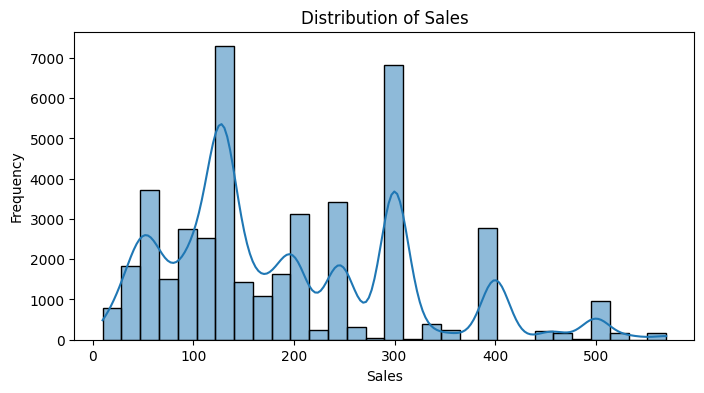

In [49]:
plt.figure(figsize=(8,4))
sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

The histogram shows that the Sales values are not normally distributed. Most sales are concentrated around 200, with additional peaks around 120 and 300. High sales values occur less frequently

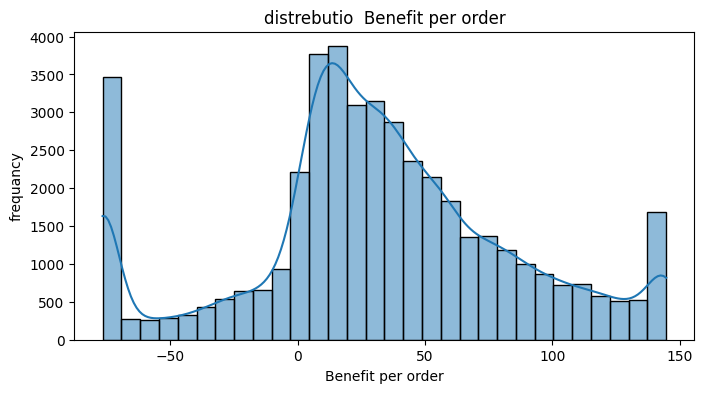

In [50]:
plt.figure(figsize=(8,4))
sns.histplot(df["Benefit per order"],bins=30 ,kde=True)
plt.title("distrebutio  Benefit per order")
plt.xlabel("Benefit per order")
plt.ylabel("frequancy")
plt.show()

The histogram shows that the distribution of "Benefit per order" is approximately symmetric. Most values are concentrated between 0 and 60, while negative and very high profit values occur less frequently.

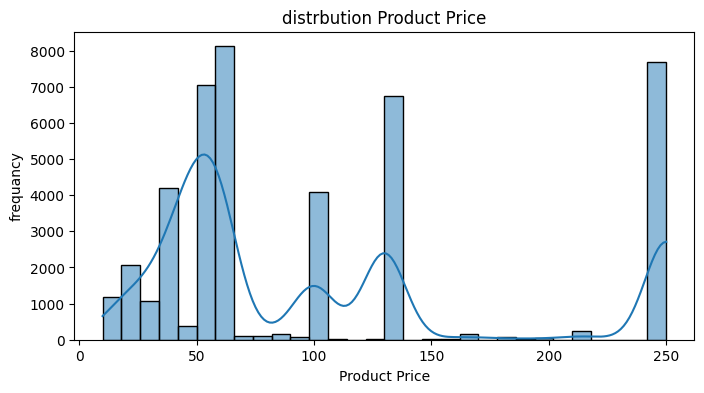

In [51]:
plt.figure(figsize=(8,4))
sns.histplot(df["Product Price"],bins=30,kde=True)
plt.title("distrbution Product Price")
plt.xlabel("Product Price")
plt.ylabel("frequancy")
plt.show()

The histogram of Product Price shows that most products have low to medium prices, while only a few products have high prices. The skewness value is 1.17, indicating a high positive skew

(8) corraletion

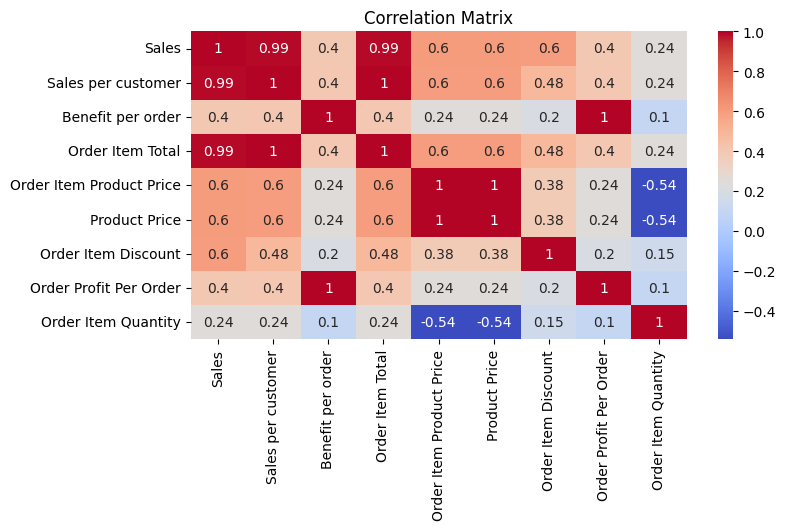

In [52]:
cols = [
    "Sales",
    "Sales per customer",
    "Benefit per order",
    "Order Item Total",
    "Order Item Product Price",
    "Product Price",
    "Order Item Discount",
    "Order Profit Per Order",
    "Order Item Quantity"
]

corr = df[cols].corr()

plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

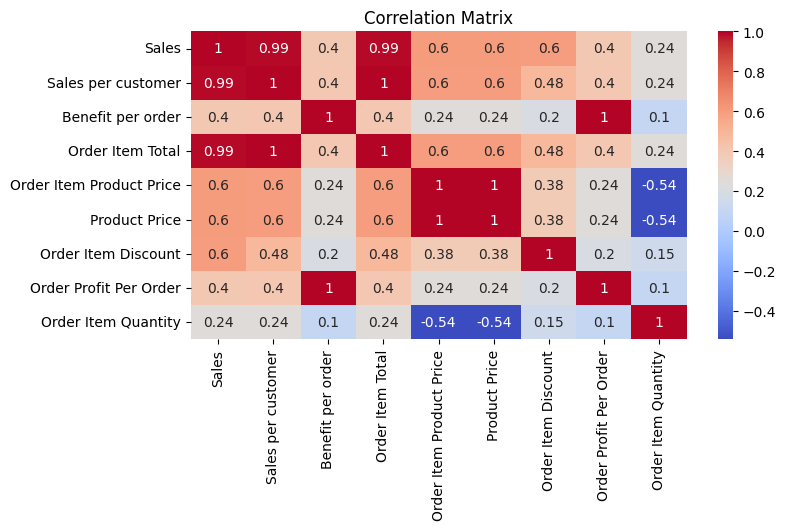

In [53]:
df[["Sales", "Order Item Total"]].corr()

plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Correlation analysis was performed to identify relationships between numerical variables. Strong positive correlations were observed between Sales and Order Item Total (0.99), Sales and Sales per Customer (0.99), and Product Price and Order Item Product Price (1.00). A moderate negative correlation (-0.52) was observed between Product Price and Order Item Quantity, indicating that higher product prices are associated with lower order quantities.

(9) feature engineering

In [54]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [55]:
df["Profit Margin (%)"] = (df["Benefit per order"] / df["Sales"]) * 100

In [56]:
df[["Sales", "Benefit per order", "Profit Margin (%)"]].head()

,Sales,Benefit per order,Profit Margin (%)
0,327.75,91.250000,27.841342
1,327.75,-76.531250,-23.350496
2,327.75,-76.531250,-23.350496
3,327.75,22.860001,6.974829
4,327.75,134.210007,40.948896


Profit Margin (%) was created to measure the percentage of profit earned from each sale. It helps evaluate how profitable each order is

In [60]:
df["Total Discount"] = (df["Order Item Product Price"] * df["Order Item Quantity"]) - df["Order Item Total"]

In [61]:
df[["Order Item Product Price", "Order Item Quantity", "Order Item Total", "Total Discount"]].head(10)

,Order Item Product Price,Order Item Quantity,Order Item Total,Total Discount
0,249.975014,1.0,314.640015,-64.665001
1,249.975014,1.0,311.359985,-61.384972
2,249.975014,1.0,309.720001,-59.744987
3,249.975014,1.0,304.809998,-54.834984
4,249.975014,1.0,298.250000,-48.274986
5,249.975014,1.0,294.980011,-45.004997
6,249.975014,1.0,288.420013,-38.445000
7,249.975014,1.0,285.140015,-35.165001
8,249.975014,1.0,278.589996,-28.614983
9,249.975014,1.0,275.309998,-25.334984


Total Discount was created to calculate the total discount applied to each order by comparing the original product value with the final order total

In [62]:
df["Shipping Delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

In [63]:
df[["Shipping Delay","Days for shipping (real)","Days for shipment (scheduled)"]].head(10)

,Shipping Delay,Days for shipping (real),Days for shipment (scheduled)
0,-1,3,4
1,1,5,4
2,0,4,4
3,-1,3,4
4,-2,2,4
5,2,6,4
6,1,2,1
7,1,2,1
8,1,3,2
9,1,2,1


Shipping Delay was created to measure the difference between the actual shipping time and the scheduled shipping time. This feature helps identify delayed or early deliveries

(10) Normalization

In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Sales_Normalized"] = scaler.fit_transform(df[["Sales"]])

In [65]:
df[["Sales", "Sales_Normalized"]].head(10)

,Sales,Sales_Normalized
0,327.75,0.567499
1,327.75,0.567499
2,327.75,0.567499
3,327.75,0.567499
4,327.75,0.567499
5,327.75,0.567499
6,327.75,0.567499
7,327.75,0.567499
8,327.75,0.567499
9,327.75,0.567499


Normalization was applied to the Sales column using Min-Max Scaling to scale the values between 0 and 1. This helps prepare the data for machine learning models and ensures that features with larger values do not dominate the analysis

(11) encoding

In [66]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Delivery Status Encoded"] = encoder.fit_transform(df["Delivery Status"])

In [67]:
df[["Delivery Status", "Delivery Status Encoded"]].head(10)

,Delivery Status,Delivery Status Encoded
0,Advance shipping,0
1,Late delivery,1
2,Shipping on time,3
3,Advance shipping,0
4,Advance shipping,0
5,Shipping canceled,2
6,Late delivery,1
7,Late delivery,1
8,Late delivery,1
9,Late delivery,1


 Encoding was applied to the Shipping Status column to convert categorical values into numerical values. This transformation makes the data suitable for machine learning algorithms while preserving each category as a unique label

(12) visualization

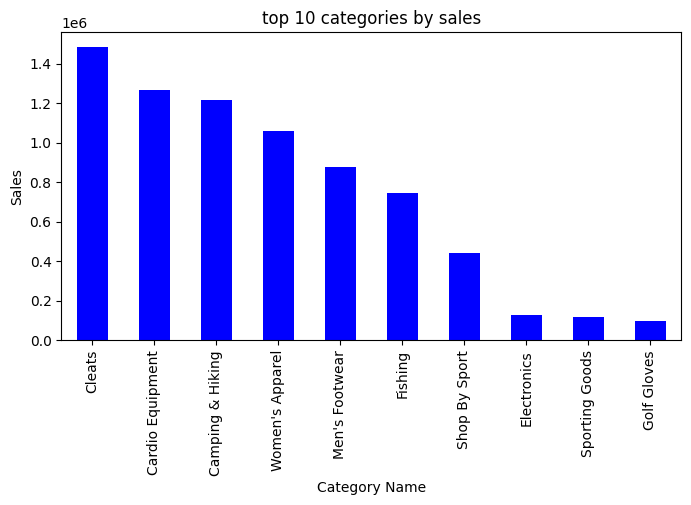

In [68]:
top_category= df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
top_category.plot(kind="bar",color="blue")

plt.title("top 10 categories by sales")
plt.xlabel("Category Name")
plt.ylabel("Sales")
plt.show()

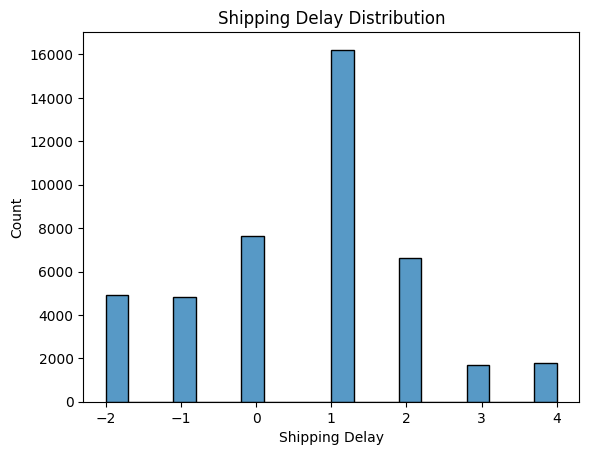

In [69]:
sns.histplot(df["Shipping Delay"], bins=20)

plt.title("Shipping Delay Distribution")

plt.show()

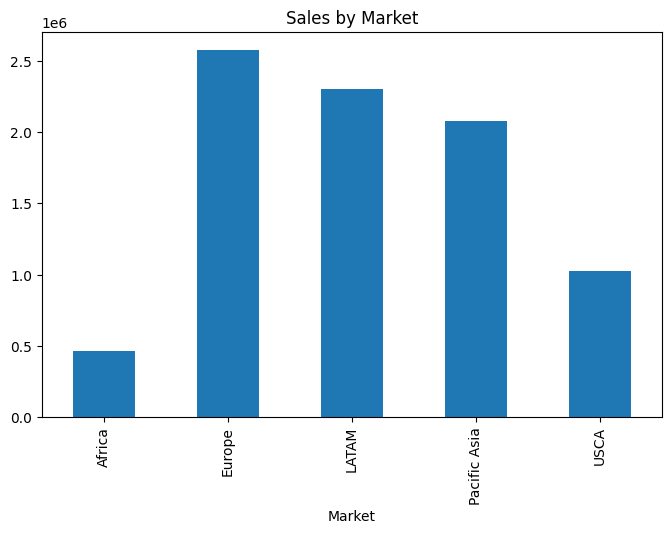

In [70]:
market_sales = df.groupby("Market")["Sales"].sum()

plt.figure(figsize=(8,5))
market_sales.plot(kind="bar")
plt.title("Sales by Market")
plt.show()

##########################################


upload 2nd tale to clean

In [71]:
df2=pd.read_csv("/content/tokenized_access_logs.csv")

explore data

In [72]:
df2.head()

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20so...
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20...
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/...
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/prod...
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports...


In [73]:
df2.shape

(330150, 8)

In [74]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330150 entries, 0 to 330149
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Product     330150 non-null  object
 1   Category    330150 non-null  object
 2   Date        330150 non-null  object
 3   Month       330150 non-null  object
 4   Hour        330150 non-null  int64 
 5   Department  330150 non-null  object
 6   ip          330150 non-null  object
 7   url         330150 non-null  object
dtypes: int64(1), object(7)
memory usage: 20.2+ MB


In [75]:
df2.describe()

,Hour
count,330150.000000
mean,15.078997
std,5.294003
min,0.000000
25%,11.000000
50%,15.000000
75%,20.000000
max,23.000000


find missing values

In [76]:
df2.isnull().sum()

,0
Product,0
Category,0
Date,0
Month,0
Hour,0
Department,0
ip,0
url,0


In [77]:
df2["Month"]=df2["Month"].fillna("0")
df2["Hour"]=df2["Hour"].fillna("0")
df2["Department"]=df2["Department"].fillna("unknowen")
df2["ip"]=df2["ip"].fillna("0")
df2["url"]=df2["url"].fillna("not found")

In [78]:
df2.isnull().sum()

,0
Product,0
Category,0
Date,0
Month,0
Hour,0
Department,0
ip,0
url,0


In [79]:
df2.duplicated().sum()

np.int64(3202)

In [80]:
df2 = df2.drop_duplicates()

In [81]:
df2.duplicated().sum()

np.int64(0)

In [82]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326948 entries, 0 to 330149
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Product     326948 non-null  object
 1   Category    326948 non-null  object
 2   Date        326948 non-null  object
 3   Month       326948 non-null  object
 4   Hour        326948 non-null  int64 
 5   Department  326948 non-null  object
 6   ip          326948 non-null  object
 7   url         326948 non-null  object
dtypes: int64(1), object(7)
memory usage: 22.4+ MB


In [83]:
df2["Date"] = pd.to_datetime(df2["Date"])

In [84]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326948 entries, 0 to 330149
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Product     326948 non-null  object        
 1   Category    326948 non-null  object        
 2   Date        326948 non-null  datetime64[ns]
 3   Month       326948 non-null  object        
 4   Hour        326948 non-null  int64         
 5   Department  326948 non-null  object        
 6   ip          326948 non-null  object        
 7   url         326948 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 22.4+ MB


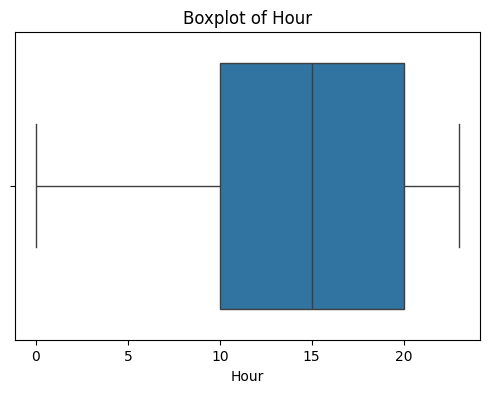

In [85]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2["Hour"])

plt.title("Boxplot of Hour")
plt.show()

In [86]:
df2.to_csv("cleaned_table.csv", index=False)

In [87]:
from google.colab import files

files.download("cleaned_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')